## Temporal Plots
Temporal Mapper constructs a graph which does not have an inherent visualization. Moreover, if your data has $d$ semantic dimensions, then the graph 'naturally' lives in $d+1$ dimensions when including time.

A temporal plot of a `TemporalMapper` is a 2d plot where the $x$-axis of a vertex is the median time of its corresponding cluster. For the $y$-axis, you can either pass a 1d reduction of your data or you can use an optimization algorithm to minimize the number of edge crossings. 

Let's demonstrate a Temporal Plot by fitting a `TemporalMapper` to a small dataset of 10,000 arXiv machine learning papers. The paper's titles and abstracts were concatenated and embedded using the sentence transformer [all-mpnet-base-v2](https://huggingface.co/sentence-transformers/all-mpnet-base-v2), and then reduced to 2D with UMAP.

In [1]:
import temporalmapper as tm
import temporalmapper.utilities as tmutils
import temporalmapper.weighted_clustering as tmwc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests, io
from sklearn.cluster import DBSCAN
from fast_hdbscan import HDBSCAN
import datamapplot as dmp

In [2]:
map_data = np.load('../data/ai_arxiv_coordinates.npy')
df = pd.read_feather('../data/ai_arxiv_data.feather')
df.head()

,title,abstract,id,created,authors,arxiv,doi
0,automated rating of recorded classroom present...,effective presentation skills can help to succ...,1801.00453,2018-01-01,"[akzharkyn izbassarova, aidana irmanova, a. p....",cs.ai,10.1109/icacci.2017.8125872
1,accelerating deep learning with memcomputing,restricted boltzmann machines (rbms) and their...,1801.00512,2018-01-01,"[haik manukian, fabio l. traversa, massimilian...",cs.ai,
2,accelerating deep learning with memcomputing,restricted boltzmann machines (rbms) and their...,1801.00512,2018-01-01,"[haik manukian, fabio l. traversa, massimilian...",cs.lg,
3,accurate reconstruction of image stimuli from ...,"in neuroscience, all kinds of computation mode...",1801.00602,2018-01-02,"[kai qiao, chi zhang, linyuan wang, bin yan, j...",cs.ai,
4,deep learning: a critical appraisal,although deep learning has historical roots go...,1801.00631,2018-01-02,[gary marcus],cs.lg,


In [3]:
# Compute a time column T which is the number of days since Jan 01, 2018.
def date_to_T(date):
    d0 = pd.Timestamp('2018-01-01')
    delta = date-d0
    return delta.days

df["date"] = pd.to_datetime(df["created"])
df["T"] = df["date"].apply(
    lambda x: date_to_T(x)
)
time = df["T"].to_numpy()

In [4]:
clusterer = HDBSCAN(
    cluster_selection_method='eom',
    min_cluster_size=20,
)
mapper = tm.TemporalMapper(
    time,
    map_data,
    clusterer,
    slice_method = 'data',
    N_checkpoints = 8,
    kernel=tmwc.square
)
mapper.fit()

### Static Temporal Plots

Now that we've fit a `TemporalMapper`, we can call its `temporal_plot` method which returns a matplotlib axis:

<Axes: >

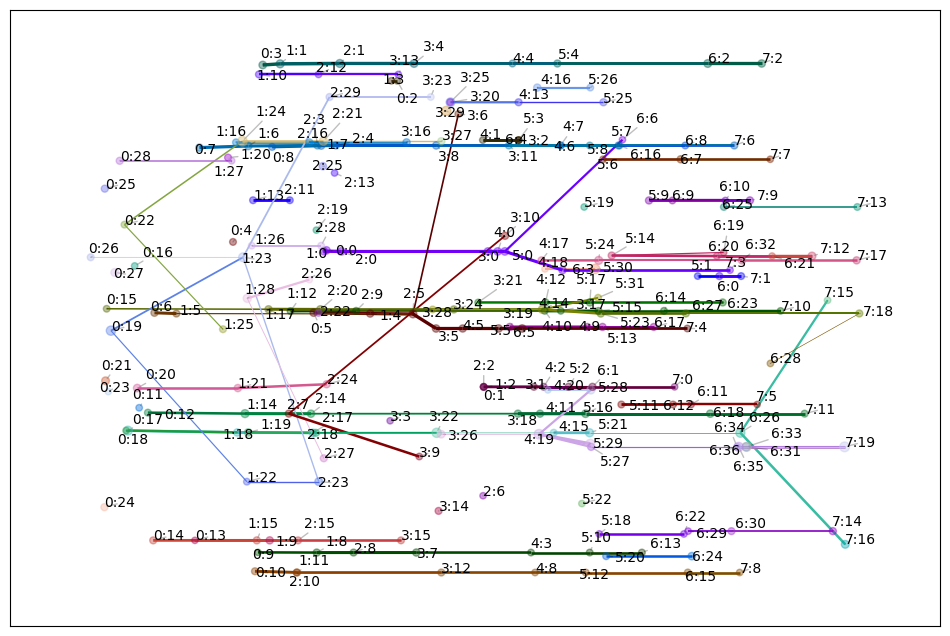

In [5]:
mapper.temporal_plot()

By default, each vertex is labeled with `t:c` where `t` is the index of the temporal slice of the vertex, and `c` is the cluster number within that slice. 

The optional `ax` argument allows you to pass a pre-made matplotlib axis, allowing you to add additional information to the plot as you wish.

We can also use the `generate_keyword_labels` function from `temporalmapper.utilities` to generate some keywords to use as labels for the vertices. This function takes a bag-of-words for each datapoint as input. To keep it simple, we'll split the abstract and title on spaces, this won't give great labels, but its better than nothing.

Generating keywords: 100%|██████████| 8/8 [00:01<00:00,  4.64it/s]


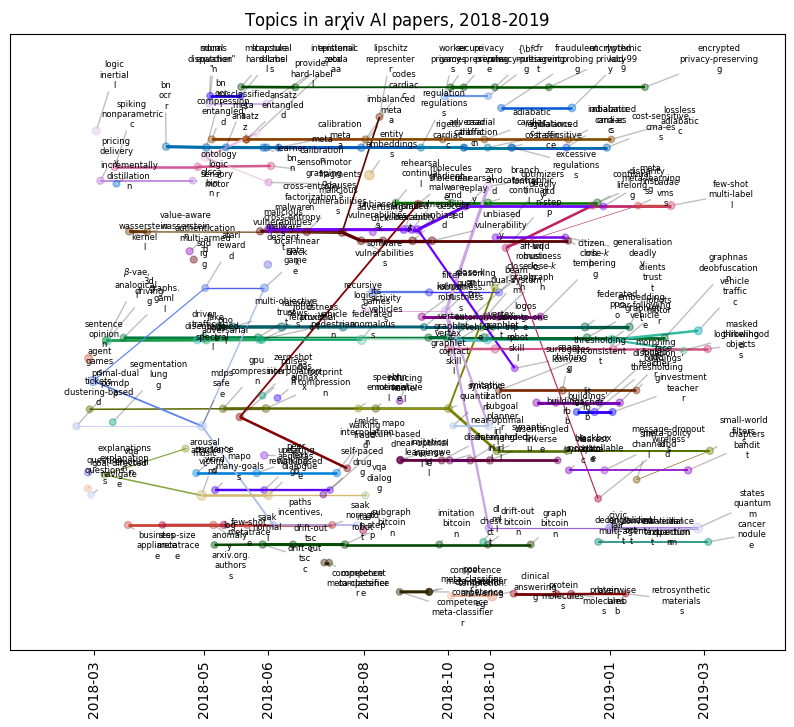

In [6]:
from sklearn.decomposition import PCA
from datetime import datetime, timedelta

## Generate informative keywords
content = (df['title']+df['abstract']).to_numpy()
word_bags = []
for c in content:
    word_bags.append(c.split(" "))

cluster_labels = tmutils.generate_keyword_labels(word_bags, mapper, sep='\n')

## Create Temporal Plot
fig, ax = plt.subplots(1,1)
mapper.temporal_plot(
    ax=ax,
    cluster_labels=cluster_labels,
    cluster_label_kwargs={"fontsize":6},
)
label_times = mapper.checkpoints
label_dates = [
    (pd.Timestamp('2018-01-01')+timedelta(days=int(x))).strftime('%Y-%m')
     for x in label_times
]
ax.set_xticks(label_times,labels=label_dates)
ax.tick_params(axis='x', labelrotation=90)
fig.set_figwidth(10)
fig.set_figheight(8)
ax.set_title("Topics in ar$\chi$iv AI papers, 2018-2019")
ax.tick_params(bottom=True, labelbottom=True)
plt.show()

As you can see, for any appreciably complex dataset, the full Mapper graph will be hard to interpret. Instead, we can plot subgraphs. To plot the subgraph spanned by a list of vertices, `s`, you can pass the list to `temporal_plot` with `vertices=s`.

For example, `TemporalMapper.vertex_subgraph(node)` will return the subgraph spanned by all the ancestors and descendants of `node`.

In [7]:
mapper.vertex_subgraph('1:4')

array(['0:5', '1:4', '2:5', '3:5', '3:6', '4:5', '5:5', '6:5', '7:4'],
      dtype='<U3')

We can pass this to the plotting function to see just this subgraph.

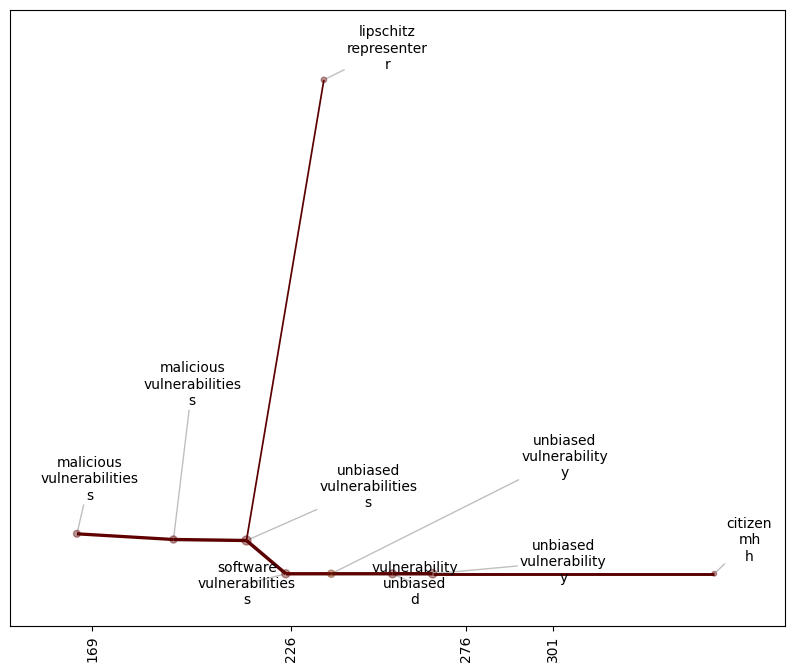

In [8]:
from sklearn.decomposition import PCA
from datetime import datetime, timedelta

y_axis =  PCA(n_components=1).fit_transform(mapper.data)

fig, ax = plt.subplots(1,1)


mapper.temporal_plot(
    ax=ax,
    vertices=mapper.vertex_subgraph('1:4'),
    cluster_labels=cluster_labels,
    cluster_label_kwargs={"fontsize":10},
)

ax.tick_params(bottom=True, labelbottom=True)
fig.set_figwidth(10)
fig.set_figheight(8)
plt.show()

The `temporal_plot` uses `networkx`'s plotting functions, `draw_networkx_nodes` and `draw_networkx_edges`. If you want to further customize the look of the plot, you can pass dictionaries `node_kwargs` and `edge_kwargs` that will be passed along to these functions.

Other notable customizations are:

```
edge_scaling : float, default 1
    Scaling factor applied to edge weights or widths.
node_scaling : float, default 1
    Scaling factor applied to node sizes.
node_size_bounds :  tuple[float], default (5,25)
    Size bounds to clip the node sizes to.
edge_weight_bounds : tuple[float], default (0.1,1)
    Size bounds to clip the edge thicknesses to.
node_size_scale : {'linear', 'log', 'sigmoid'}, default 'sigmoid'
    Scaling mode used for node sizes.
```

### Interactive Temporal Plot

Even better than plotting subgraphs, we can generate an interactive temporal plot using Plotly.


In [9]:
fig = mapper.interactive_temporal_plot()
fig.show()

The interactive plot is not as customizable as the static plot, but you can still make some customizations:

In [10]:
fig = mapper.interactive_temporal_plot(
    hover_text=cluster_labels,
)
fig.update_layout(
    title=dict(text="Topics in arXiv AI papers, 2018-2019"),
    width=1000,
    height=600,
)
fig.show()